# Tests the model properly - on data it has NOT been trained on.

Notebook 04 used 5-fold cross-validation, which mixes all sources together.
That can hide a model that has learned "which dataset is this from" rather
than "is this phishing". This notebook runs the tests that expose that:

  1. LEAVE-ONE-SOURCE-OUT: train on six sources, test on  mji;99ithe seventh, rotate.
     If scores hold up on an unseen source, the model is learning phishing.
  2. CALIBRATION: does "80% phishing" actually mean 80%? (Matters for the app.)
  3. THRESHOLDS: what happens to recall/precision if the app flags at 30%, 50%, 70%?
  4. HELD-OUT TEST SETS: any extra test file with text + label columns,
     e.g. a self-built education set.
  5. EXPLAINABILITY: which words push the model towards "phishing"? (Feeds the app.)
  6. DEMONSTRATION: the tool on 15 real and simulated education emails.

In [3]:
#Connect to Drive, load data, the helper file and the saved model

from google.colab import drive
drive.mount('/content/drive')

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

project = "/content/drive/MyDrive/Colab Notebooks/Master's project"
data_folder = os.path.join(project, "Data")
model_folder = os.path.join(project, "Model")
results_folder = os.path.join(project, "Results")
os.makedirs(results_folder, exist_ok=True)

sys.path.append(model_folder)
import features

train = pd.read_csv(os.path.join(data_folder, "phishing_general_clean.csv"))
train["text"] = train["text"].fillna("").astype(str)
train["text_clean"] = train["text_clean"].fillna("").astype(str)

X = features.make_frame(train["text"], clean_texts=train["text_clean"])
y = train["label"].values
sources = train["source"].values

final_model = joblib.load(os.path.join(model_folder, "phishing_model.joblib"))
print(open(os.path.join(model_folder, "model_info.txt")).read())

Mounted at /content/drive



In [4]:
# Rebuild the same pipeline recipe as 04_training_models
# Leave-one-source-out needs to train fresh copies of the model, so the recipe must be the same as the one that made the saved model.
# IMPORTANT IF REPLICATING: if you change settings in 04_training_models, change them here too.

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def tfidf():
    return TfidfVectorizer(ngram_range=(1, 2), max_features=30000, min_df=3,
                           sublinear_tf=True, stop_words="english")

feature_sets = {
    "A: TF-IDF only": lambda: ColumnTransformer([("tfidf", tfidf(), "text_clean")]),
    "B: TF-IDF + structural": lambda: ColumnTransformer([
        ("tfidf", tfidf(), "text_clean"),
        ("struct", MinMaxScaler(), features.STRUCTURAL_COLUMNS)]),
}
models = {
    "Logistic Regression": lambda: LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced", random_state=42),
    "Random Forest":       lambda: RandomForestClassifier(n_estimators=200, max_features="sqrt", class_weight="balanced", n_jobs=-1, random_state=42),
    "SVM (linear)":        lambda: LinearSVC(C=0.5, class_weight="balanced", random_state=42),
}

# The recipe the saved model used
chosen_feature_set = "B: TF-IDF + structural"
chosen_model = "SVM (linear)"
print("Evaluating recipe:", chosen_feature_set, "/", chosen_model)
print(open(os.path.join(model_folder, "model_info.txt")).read())

def build_pipeline():
    base = Pipeline([("features", feature_sets[chosen_feature_set]()),
                     ("model", models[chosen_model]())])
    return CalibratedClassifierCV(base, method="isotonic", cv=5)   # calibrated, so it can give probabilities

Evaluating recipe: B: TF-IDF + structural / SVM (linear)



In [5]:
# A scoring helper
# Given true labels and predicted probabilities, returns the metrics I report.
# Some sources contain only ONE class (e.g. Nigerian_Fraud is all phishing).
# For those, precision and AUC do not make sense, so they are left blank and only recall (or, for an all-legitimate source, the false-alarm rate) is shown.

from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix

def score(y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    out = {"n": len(y_true), "phishing_share": y_true.mean()}
    if y_true.min() == y_true.max():                      # only one class present
        if y_true[0] == 1:
            out["recall"] = recall_score(y_true, pred)    # share of phishing caught
        else:
            out["false_alarm_rate"] = pred.mean()          # share of legit emails wrongly flagged
        return out
    out["recall"] = recall_score(y_true, pred)
    out["precision"] = precision_score(y_true, pred, zero_division=0)
    out["f1"] = f1_score(y_true, pred)
    out["auc"] = roc_auc_score(y_true, prob)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    out["false_alarm_rate"] = fp / max(fp + tn, 1)
    return out

In [10]:
# Leave-one-source-out (trains the model 14 times so this is very slow)
# For each source: train on every OTHER source, test on this one.
# I do this for BOTH feature sets (A and B) with the chosen model, because 04_training_models could not separate them and they both scored ~99% on the easy random split.
# This harder test is where a difference could show.

import time
loso = []
for fs_name in feature_sets:
    for src in sorted(np.unique(sources)):
        t0 = time.time()
        test_mask = sources == src
        base = Pipeline([("features", feature_sets[fs_name]()),
                         ("model", models[chosen_model]())])
        pipe = CalibratedClassifierCV(base, method="isotonic", cv=5)
        pipe.fit(X[~test_mask], y[~test_mask])
        prob = pipe.predict_proba(X[test_mask])[:, 1]
        row = {"feature_set": fs_name, "held_out_source": src, **score(y[test_mask], prob)}
        row["minutes"] = (time.time() - t0) / 60
        loso.append(row)
        print(f"{fs_name:24s} {src:20s} " +
              " | ".join(f"{k} {v:.3f}" for k, v in row.items()
                         if isinstance(v, float) and k not in ("minutes", "phishing_share")))

loso = pd.DataFrame(loso)
loso.round(3).to_csv(os.path.join(results_folder, "table_leave_one_source_out.csv"), index=False)
print("\n", loso.round(3).to_string(index=False))


A: TF-IDF only           CEAS_08              recall 0.811 | precision 0.928 | f1 0.866 | auc 0.955 | false_alarm_rate 0.063
A: TF-IDF only           Enron                recall 0.924 | precision 0.757 | f1 0.832 | auc 0.922 | false_alarm_rate 0.267
A: TF-IDF only           Ling                 recall 0.926 | precision 0.635 | f1 0.753 | auc 0.975 | false_alarm_rate 0.102
A: TF-IDF only           Nazario              recall 0.651
A: TF-IDF only           Nigerian_Fraud       recall 0.989
A: TF-IDF only           SpamAssasin          recall 0.967 | precision 0.735 | f1 0.836 | auc 0.980 | false_alarm_rate 0.143
A: TF-IDF only           kuladeep_synthetic   recall 0.873 | precision 0.995 | f1 0.930 | auc 0.993 | false_alarm_rate 0.007
B: TF-IDF + structural   CEAS_08              recall 0.817 | precision 0.916 | f1 0.864 | auc 0.952 | false_alarm_rate 0.074
B: TF-IDF + structural   Enron                recall 0.903 | precision 0.785 | f1 0.840 | auc 0.928 | false_alarm_rate 0.223
B: TF-I

5-fold CV (mixed sources, upper bound):
  A: TF-IDF only           F1 0.989  recall 0.990  AUC 0.999
  B: TF-IDF + structural   F1 0.990  recall 0.990  AUC 0.999

Leave-one-source-out (average over sources with both classes):
  A: TF-IDF only           F1 0.843  recall 0.900  AUC 0.965
  B: TF-IDF + structural   F1 0.851  recall 0.901  AUC 0.966


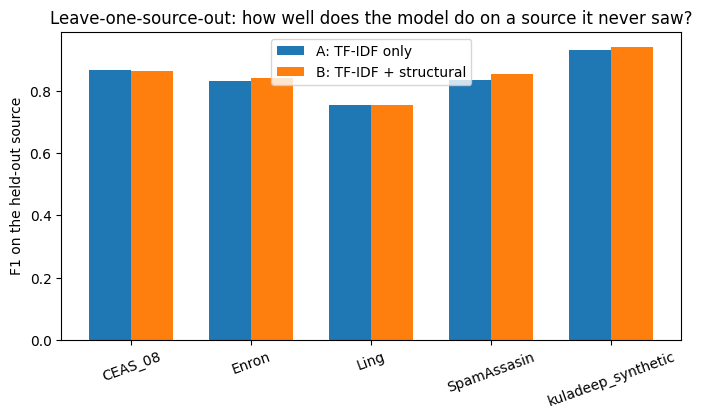

In [11]:
# Compare to the 5-fold result from 04_training_models
# If leave-one-source-out scores are far below the 5-fold scores, the 5-fold number was inflated by source shortcuts. The gap itself is a finding.
# Only sources that contain BOTH classes have an F1, so the averages below use those sources only.

cv_table = pd.read_csv(os.path.join(data_folder, "table_cv_results.csv"))
print("5-fold CV (mixed sources, upper bound):")
for fs_name in feature_sets:
    r = cv_table[(cv_table["feature_set"] == fs_name) & (cv_table["model"] == chosen_model)].iloc[0]
    print(f"  {fs_name:24s} F1 {r['f1']:.3f}  recall {r['recall']:.3f}  AUC {r['auc']:.3f}")

print("\nLeave-one-source-out (average over sources with both classes):")
summary = []
for fs_name in feature_sets:
    sub = loso[(loso["feature_set"] == fs_name)].dropna(subset=["f1"])
    row = {"feature_set": fs_name, "sources": len(sub),
           "f1": sub["f1"].mean(), "recall": sub["recall"].mean(),
           "precision": sub["precision"].mean(), "auc": sub["auc"].mean()}
    summary.append(row)
    print(f"  {fs_name:24s} F1 {row['f1']:.3f}  recall {row['recall']:.3f}  AUC {row['auc']:.3f}")
pd.DataFrame(summary).round(3).to_csv(os.path.join(results_folder, "table_loso_summary.csv"), index=False)

# Chart: F1 per held-out source, A vs B
two = loso.dropna(subset=["f1"])
srcs = sorted(two["held_out_source"].unique())
plt.figure(figsize=(8, 4))
w = 0.35
for i, fs_name in enumerate(feature_sets):
    vals = [two[(two["feature_set"] == fs_name) & (two["held_out_source"] == s)]["f1"].values[0] for s in srcs]
    plt.bar(np.arange(len(srcs)) + (i - 0.5) * w, vals, w, label=fs_name)
plt.xticks(np.arange(len(srcs)), srcs, rotation=20)
plt.ylabel("F1 on the held-out source")
plt.title("Leave-one-source-out: how well does the model do on a source it never saw?")
plt.legend()
plt.savefig(os.path.join(results_folder, "fig_leave_one_source_out.png"), dpi=150, bbox_inches="tight")
plt.show()


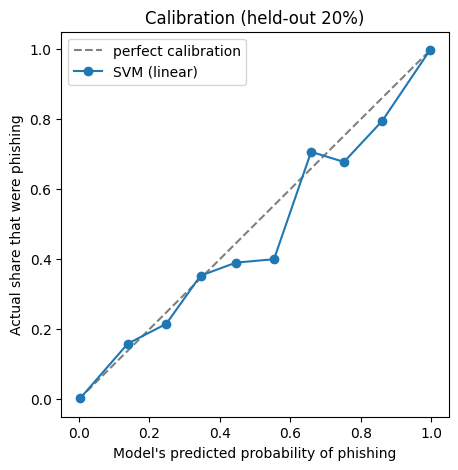

Brier score (lower is better, 0 = perfect): 0.0081


In [12]:
# Calibration: does the percentage mean what it says?
# I hold back 20% of the training data, train a fresh calibrated model on the  other 80%, and compare what the model SAYS (e.g. "70%") with what actually happens (how many of those emails were really phishing).
# A perfectly calibrated model sits on the diagonal line.

from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve

idx_train, idx_test = train_test_split(np.arange(len(X)), test_size=0.2, random_state=42, stratify=y)
cal_model = build_pipeline()
cal_model.fit(X.iloc[idx_train], y[idx_train])
prob_test = cal_model.predict_proba(X.iloc[idx_test])[:, 1]
y_test = y[idx_test]

frac_pos, mean_pred = calibration_curve(y_test, prob_test, n_bins=10)
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "--", color="grey", label="perfect calibration")
plt.plot(mean_pred, frac_pos, "o-", label=chosen_model)
plt.xlabel("Model's predicted probability of phishing")
plt.ylabel("Actual share that were phishing")
plt.title("Calibration (held-out 20%)")
plt.legend()
plt.savefig(os.path.join(results_folder, "fig_calibration.png"), dpi=150, bbox_inches="tight")
plt.show()

from sklearn.metrics import brier_score_loss
print(f"Brier score (lower is better, 0 = perfect): {brier_score_loss(y_test, prob_test):.4f}")

 threshold  recall  precision    f1   auc  false_alarm_rate
       0.2   0.995      0.977 0.986 0.999             0.024
       0.3   0.993      0.983 0.988 0.999             0.018
       0.4   0.991      0.986 0.989 0.999             0.014
       0.5   0.990      0.989 0.989 0.999             0.011
       0.6   0.988      0.991 0.990 0.999             0.009
       0.7   0.983      0.993 0.988 0.999             0.007
       0.8   0.979      0.995 0.987 0.999             0.005


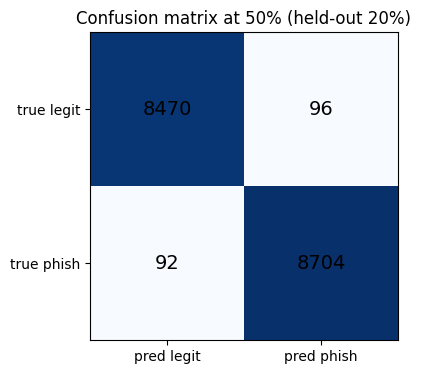

In [13]:
# Thresholds: what should the app treat as "suspicious"?
# The app shows a percentage, but it also needs to decide when to warn.
# This table shows the trade-off: a lower threshold catches more phishing (higher recall) but flags more legitimate emails (higher false-alarm rate).

rows = []
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    rows.append({"threshold": t, **{k: v for k, v in score(y_test, prob_test, t).items() if k not in ("n", "phishing_share")}})
thresholds = pd.DataFrame(rows).round(3)
print(thresholds.to_string(index=False))
thresholds.to_csv(os.path.join(results_folder, "table_thresholds.csv"), index=False)

# Confusion matrix at 50%
pred = (prob_test >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
plt.xticks([0, 1], ["pred legit", "pred phish"]); plt.yticks([0, 1], ["true legit", "true phish"])
plt.title("Confusion matrix at 50% (held-out 20%)")
plt.savefig(os.path.join(results_folder, "fig_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Held-out test sets
# Any CSV in the Data folder with "text" and "label" columns can go here.
# The FINAL saved model (trained on all general data) is used, so this is a true test on unseen data.
#   - Synthetic education set: 80 AI-written emails (40 phishing, 40 legitimate) in UK school and university settings. Indicative only: one generator, one style, and the training data already includes one LLM-written corpus.
#   - EduPhish is included for REFERENCE ONLY: notebook 03 showed it overlaps with the training data, so its score will be inflated.
# Not evidence of generalisation.

test_sets = {
    "Synthetic education (AI-written, 80)":     "synthetic_education_emails.csv",
    "EduPhish decontaminated (reference only)": "phishing_education_decontaminated_clean.csv",
    "EduPhish strict (reference only)":         "phishing_education_strict_clean.csv",
}

held_out = []
for name, filename in test_sets.items():
    path = os.path.join(data_folder, filename)
    if not os.path.exists(path):
        print(f"skipping {name}: {filename} not found")
        continue
    t = pd.read_csv(path)
    t["text"] = t["text"].fillna("").astype(str)
    clean = t["text_clean"].fillna("").astype(str) if "text_clean" in t.columns else None
    prob = final_model.predict_proba(features.make_frame(t["text"], clean_texts=clean))[:, 1]
    held_out.append({"test_set": name, **score(t["label"].values, prob)})

held_out = pd.DataFrame(held_out).round(3)
print(held_out.to_string(index=False))
held_out.to_csv(os.path.join(results_folder, "table_held_out_tests.csv"), index=False)

                                test_set     n  phishing_share  recall  precision    f1   auc  false_alarm_rate
    Synthetic education (AI-written, 80)    80           0.500   0.725      0.806 0.763 0.877             0.175
EduPhish decontaminated (reference only) 12165           0.449   0.884      0.961 0.920 0.978             0.030
        EduPhish strict (reference only)  3201           0.453   0.878      0.967 0.920 0.972             0.025


In [15]:
# Explainability: which words matter?
# For Logistic Regression and SVM, each word has a weight: positive pushes towards "phishing", negative towards "legitimate".
# For Random Forest there is an importance score instead (no direction). This is the raw material for the plain-language explanations in the app.

# The calibrated model wraps several copies of the pipeline; take the first
one = final_model.calibrated_classifiers_[0].estimator
col_tf = one.named_steps["features"]
model_step = one.named_steps["model"]

names = list(col_tf.named_transformers_["tfidf"].get_feature_names_out())
if "struct" in col_tf.named_transformers_:
    names += features.STRUCTURAL_COLUMNS
names = np.array(names)

if hasattr(model_step, "coef_"):
    w = model_step.coef_.ravel()
    top_phish = names[np.argsort(w)[::-1][:25]]
    top_legit = names[np.argsort(w)[:25]]
    print("Top 25 features pushing towards PHISHING:\n ", ", ".join(top_phish))
    print("\nTop 25 features pushing towards LEGITIMATE:\n ", ", ".join(top_legit))
    pd.DataFrame({"feature": names, "weight": w}).sort_values("weight", ascending=False)\
      .to_csv(os.path.join(results_folder, "table_feature_weights.csv"), index=False)
else:
    imp = model_step.feature_importances_
    print("Top 25 most important features (no direction):\n ", ", ".join(names[np.argsort(imp)[::-1][:25]]))
    pd.DataFrame({"feature": names, "importance": imp}).sort_values("importance", ascending=False)\
      .to_csv(os.path.join(results_folder, "table_feature_importance.csv"), index=False)

print("\nAll tables and figures saved to:", results_folder)

Top 25 features pushing towards PHISHING:
  account, mobile, http, kindly, love, life, wetransfer, click, secure, utf, n_exclaim, meds, sex, watches, remove, watch, notification, income, sir, pills, man, inches, quality, vicodin, remedy

Top 25 features pushing towards LEGITIMATE:
  wrote, rant, vince, louise, opensuse, fork, thanks, university, employees, tony, n_urls, language, uai, 713, postfix, energy, kaminski, questions, comments, slideshow, jeff, python, following, dave, perl

All tables and figures saved to: /content/drive/MyDrive/Colab Notebooks/Master's project/Results


In [5]:
# Illustrative demonstration on 15 education examples 7 real university phishing emails (UWE, Bristol, Birmingham) and 8 simulated secondary-school emails (5 phishing, 3 legitimate).
# This is NOT an evaluation because 15 emails cannot give a reliable score, but it shows what the tool does on the kind of email it is for, and where it struggles (e.g. emails whose only danger is an attachment).

demo = pd.read_csv(os.path.join(data_folder, "demo_dataset.csv"))
demo["prob"] = final_model.predict_proba(features.make_frame(demo["text"]))[:, 1]
demo["pct"] = (demo["prob"] * 100).round(0).astype(int)
demo["verdict_at_50"] = np.where(demo["prob"] >= 0.5, "phishing", "legitimate")
demo["correct"] = ((demo["prob"] >= 0.5).astype(int) == demo["label"])

print(demo[["id", "setting", "type", "label", "pct", "correct"]].to_string(index=False))
print("\nCorrect at 50% threshold:", demo["correct"].sum(), "of", len(demo))
demo.to_csv(os.path.join(results_folder, "table_demo_examples_scored.csv"), index=False)

       id          setting                                                          type  label  pct  correct
   uni_01       university                                        Sextortion / blackmail      1   95     True
   uni_02       university              Government impersonation / credential harvesting      1   96     True
   uni_03       university                         Fake helpdesk / credential harvesting      1   85     True
   uni_04       university           Malicious attachment from compromised staff account      1   91     True
   uni_05       university        Fake IT helpdesk / mailbox quota credential harvesting      1   98     True
   uni_06       university               Government impersonation / malicious attachment      1   80     True
   uni_07       university                   Compromised supplier / malicious attachment      1    9    False
school_01 secondary school                    Headteacher impersonation / gift-card scam      1    5    False
school_02 

In [6]:
# Near-copy check on the two new files (for the record)
# Confirms that neither the synthetic set nor the demo examples overlap with the training data. Expecting zero for both.

import re
def strong_key(t):
    t = re.sub(r"[^a-z0-9 ]", " ", str(t).lower())
    return " ".join(t.split()[:40])

train_keys = set(train["text"].apply(strong_key))
for name in ["synthetic_education_emails.csv", "demo_dataset.csv"]:
    t = pd.read_csv(os.path.join(data_folder, name))
    n = t["text"].apply(strong_key).isin(train_keys).sum()
    print(f"{name}: {n} near-copies of training data (of {len(t)})")

synthetic_education_emails.csv: 0 near-copies of training data (of 80)
demo_dataset.csv: 0 near-copies of training data (of 15)


In [6]:
# Threshold choice on CROSS-SOURCE predictions
# The 7th cell's table used a random split, where every threshold looks perfect.
# Here I collect the probabilities each email got when its source was held out, then see how recall and false alarms change with the threshold.
# This is the table the app's warning levels should be chosen from.

pooled_prob, pooled_y = [], []
for src in sorted(np.unique(sources)):
    m = sources == src
    pipe = build_pipeline()
    pipe.fit(X[~m], y[~m])
    pooled_prob.append(pipe.predict_proba(X[m])[:, 1]); pooled_y.append(y[m])
    print("done", src)
pooled_prob, pooled_y = np.concatenate(pooled_prob), np.concatenate(pooled_y)
np.save(os.path.join(results_folder, "loso_pooled_prob.npy"), pooled_prob)
np.save(os.path.join(results_folder, "loso_pooled_y.npy"), pooled_y)

rows = [{"threshold": t, **{k: v for k, v in score(pooled_y, pooled_prob, t).items() if k not in ("n", "phishing_share")}}
        for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]]
loso_thresholds = pd.DataFrame(rows).round(3)
print(loso_thresholds.to_string(index=False))
loso_thresholds.to_csv(os.path.join(results_folder, "table_thresholds_cross_source.csv"), index=False)

done CEAS_08
done Enron
done Ling
done Nazario
done Nigerian_Fraud
done SpamAssasin
done kuladeep_synthetic
 threshold  recall  precision    f1   auc  false_alarm_rate
       0.1   0.981      0.724 0.833 0.945             0.384
       0.2   0.949      0.775 0.853 0.945             0.283
       0.3   0.929      0.815 0.868 0.945             0.217
       0.4   0.902      0.845 0.873 0.945             0.170
       0.5   0.868      0.874 0.871 0.945             0.129
       0.6   0.829      0.900 0.863 0.945             0.094
       0.7   0.775      0.924 0.843 0.945             0.065
       0.8   0.704      0.948 0.808 0.945             0.040
       0.9   0.616      0.962 0.751 0.945             0.025
